# EX2


## Data Analysis using simple plots

- Review the examples of basic visualization using Python libraries and Pandas.

## Advertising data

Let's take a look at some data, ask some questions about that data, and then use linear regression to answer those questions!

A toy dataset for your exploratory data analysis:

./data/Advertising.csv

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read CSV file stored in the current directory and save the results
data = pd.read_csv('./data/Advertising.csv', skipinitialspace=True, index_col=0)

# display the first 5 rows
data.head()

,TV,Radio,Newspaper,Sales
3/11/19,230.1,37.8,69.2,22.1
3/12/19,44.5,39.3,45.1,10.4
3/13/19,17.2,45.9,69.3,9.3
3/14/19,151.5,41.3,58.5,18.5
3/15/19,180.8,10.8,58.4,12.9


What are the features?
- **TV:** advertising dollars spent on TV for a single product in a given market (in thousands of dollars)
- **Radio:** advertising dollars spent on Radio
- **Newspaper:** advertising dollars spent on Newspaper

What is the response?
- **Sales:** sales of a single product in a given market (in thousands of items)

What else do we know?
- Because the response variable is continuous, this is a **regression** problem.
- There are 200 **observations** (represented by the rows), and each observation is a single market.

In [3]:
#display all data. You can uncomment the code in the next line

#display(data)

data.shape

(200, 4)

## Part 1 Tasks

Create cells to solve each of the following problems.

(1) For each field of the data, what is the mean of the data? What is the median? Are there any dataset has mode value?

(2) For each field of the data, give the five-number summary, minimum, the first quartile (Q1), median, the third quartile (Q3), and maximum of the data.

(3) For each field of the data, visulize a boxplot of the data and compare it to your answer in (b).

(4) For Sales, visualize distribution of the data using histogram. Comment on the data’s modality (i.e., bimodal, trimodal, etc.)

(5) For Sales, visualize the trend of the data over time using a graph.

(6) For each pair (TV-Sales, Radio-Sales, Newspaper-Sales), calculate the Pearson's correlation coefficient factor r.

(7) For each pair (TV-Sales, Radio-Sales, Newspaper-Sales), visualize scatter graph.

(8) Discuss what the differences are between the three: (a) boxplot, (b) histogram, and (c) scatter plot with respect to founding.

In [16]:
# (1) Mean, Median and Mode
print("Means:\n", data.mean(numeric_only=True))
print("\nMedians:\n", data.median(numeric_only=True))
print("\nModes:\n", data.mode(numeric_only=True))

Means:
 TV           147.0425
Radio         23.2640
Newspaper     30.5540
Sales         14.0225
dtype: float64

Medians:
 TV           149.75
Radio         22.90
Newspaper     25.75
Sales         12.90
dtype: float64

Modes:
       TV  Radio  Newspaper  Sales
0   17.2    4.1        8.7    9.7
1   76.4    5.7        9.3    NaN
2  109.8    NaN       25.6    NaN
3  177.0    NaN        NaN    NaN
4  184.9    NaN        NaN    NaN
5  197.6    NaN        NaN    NaN
6  199.8    NaN        NaN    NaN
7  222.4    NaN        NaN    NaN
8  237.4    NaN        NaN    NaN
9  240.1    NaN        NaN    NaN


Technically, the dataset does return mode values, but because these variables are continuous, the modes are not meaningful.

In [9]:
# (2) Five-number summary
print("\nFive-Number Summary:\n", data.describe())


Five-Number Summary:
                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


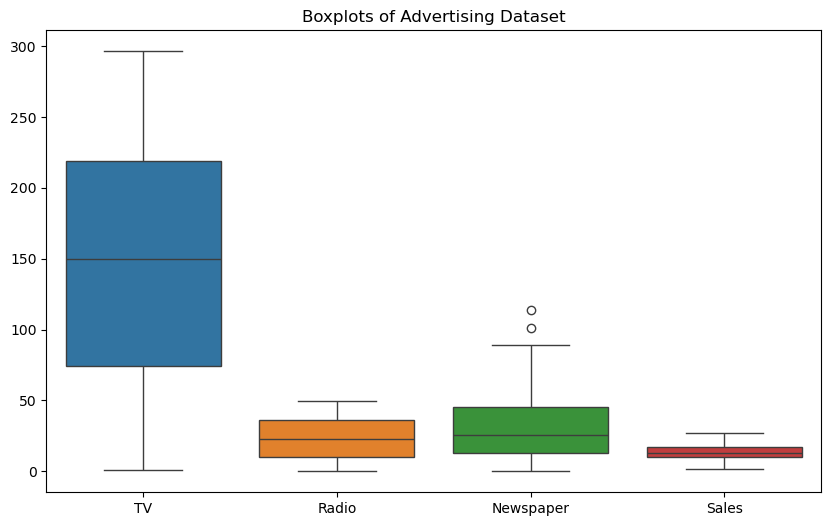

In [18]:
# (3) Boxplots for all fields
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.title("Boxplots of Advertising Dataset")
plt.show()

The boxplots visually confirm the results from the five-number summary. Variables with larger interquartile ranges in part (b), such as TV, show wider boxes, indicating greater variability. Newspaper displays visible outliers, which is consistent with its large maximum value compared to Q3 in the numerical summary. Sales has a relatively compact box and centered median, matching its smaller spread and near-symmetric distribution in part (b). 

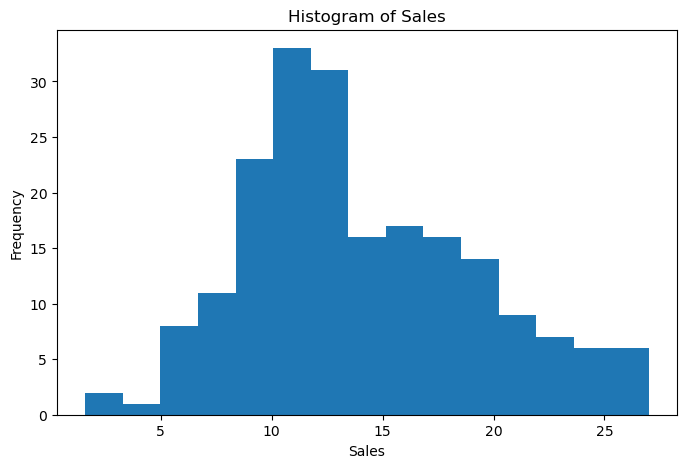

In [20]:
# (4) Sales Distribution (Histogram)
plt.figure(figsize=(8, 5))
plt.hist(data["Sales"], bins=15)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Histogram of Sales")
plt.show()

The distribution of Sales is approximately unimodal.

The distribution is approximately normal but exhibits a slight right skew.

This supports the earlier conclusion that the data is not bimodal or multimodal.

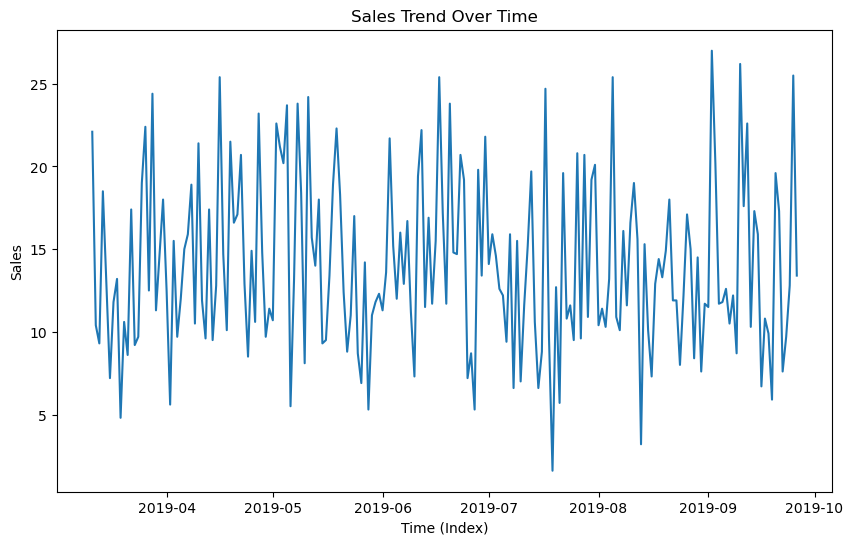

In [30]:
# (5) Sales trend over time
data.index = pd.to_datetime(data.index, format='%m/%d/%y')
    
plt.figure(figsize=(10, 6))
plt.plot(data.index, data["Sales"])
plt.xlabel("Time (Index)")
plt.ylabel("Sales")
plt.title("Sales Trend Over Time")
plt.show()

In [25]:
# (6) Pearson's Correlation Coefficient
correlations = data.corr()['Sales'].drop('Sales')
print("Correlation with Sales:\n", correlations)

Correlation with Sales:
 TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


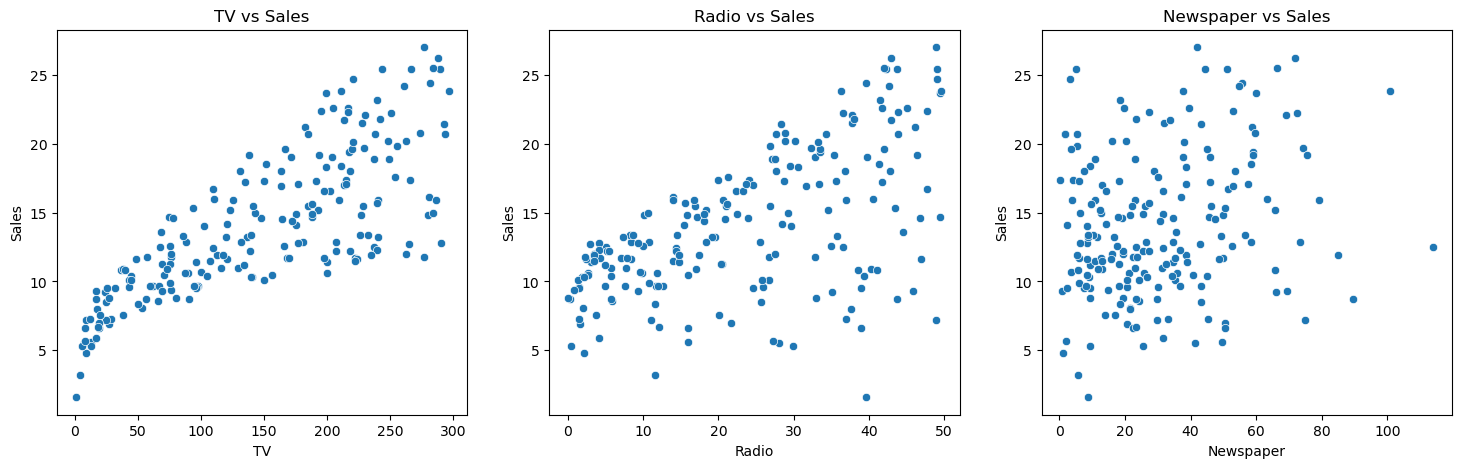

In [28]:
# (7) Scatter plots for each pair
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=data['TV'], y=data['Sales'], ax=axes[0]).set_title('TV vs Sales')
sns.scatterplot(x=data['Radio'], y=data['Sales'], ax=axes[1]).set_title('Radio vs Sales')
sns.scatterplot(x=data['Newspaper'], y=data['Sales'], ax=axes[2]).set_title('Newspaper vs Sales')
plt.show()

8) While a Boxplot might show that Newspaper spending has outliers reaching up to ~120, the Histogram shows that most markets actually spend between 0 and 40. Meanwhile, the Scatter plot is the only one that reveals that this Newspaper spending has a very weak relationship with actual Sales compared to TV.

## Part 2
It is good practice to write a summary of your findings from data anlaysis.

#### Summary
- The dataset consists of continuous numerical variables related to advertising budgets and sales.

- Exploratory analysis shows that Sales is unimodal.

- Visualization techniques reveal complementary insights:

  -  Boxplots identify variability and outliers.

  - Histograms confirm distribution shape and modality.

  - Scatter plots highlight relationships between variables.

- Correlation analysis shows that TV advertising is the strongest predictor of Sales, followed by Radio.

- Linear regression confirms a strong positive linear relationship between TV advertising spend and Sales.

- Newspaper advertising has minimal impact and may not significantly contribute to predictive models.

### Resources

#### Boxplot
https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51


- matplotlib.pyplot boxplot demo
https://matplotlib.org/3.1.1/gallery/pyplots/boxplot_demo_pyplot.html


#### matplotlib.pyplot
- scatter plot
https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.scatter.html


- histogram plot
https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.hist.html


#### pandas DataFrame
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html


- describe()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html


- corr()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html


- hist()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html


- plot.scatter()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.scatter.html


- pivot()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html